In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/tokenized_access_logs.csv
/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DataCoSupplyChainDataset.csv
/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DescriptionDataCoSupplyChain.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DataCoSupplyChainDataset.csv', encoding='cp1252')

In [3]:
print("Shape:", df.shape)

Shape: (180519, 53)


In [4]:
print("\nColumn names:\n", df.columns.tolist())


Column names:
 ['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shippin

In [5]:
print("\nData types:\n", df.dtypes)


Data types:
 Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Ma

In [6]:
print("\nNull counts:\n", df.isnull().sum()[df.isnull().sum() > 0])


Null counts:
 Customer Lname              8
Customer Zipcode            3
Order Zipcode          155679
Product Description    180519
dtype: int64


In [7]:
print("\nTarget distribution:\n", df['Late_delivery_risk'].value_counts())


Target distribution:
 Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64


In [8]:
print("\nShipping modes:\n", df['Shipping Mode'].value_counts())


Shipping modes:
 Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64


In [9]:
print("\nDelivery status:\n", df['Delivery Status'].value_counts())



Delivery status:
 Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64


In [10]:
print("\nCustomer segments:\n", df['Customer Segment'].value_counts())


Customer segments:
 Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64


In [11]:
print("\nMarkets:\n", df['Market'].value_counts())



Markets:
 Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64


# Phase 2


In [12]:
dfd = pd.read_csv('/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DescriptionDataCoSupplyChain.csv', encoding='cp1252')

In [13]:
print("Shape:", dfd.shape)

Shape: (52, 2)


In [14]:
dfd.head(52)

,FIELDS,DESCRIPTION
0,Type,: Type of transaction made
1,Days for shipping (real),: Actual shipping days of the purchased product
2,Days for shipment (scheduled),: Days of scheduled delivery of the purchased...
3,Benefit per order,: Earnings per order placed
4,Sales per customer,: Total sales per customer made per customer
5,Delivery Status,: Delivery status of orders: Advance shipping...
6,Late_delivery_risk,: Categorical variable that indicates if send...
7,Category Id,: Product category code
8,Category Name,: Description of the product category
9,Customer City,: City where the customer made the purchase


# Supply Chain Delivery Performance Analytics
## Phase 2: Data Cleaning & Exploratory Data Analysis

**Dataset:** DataCo Smart Supply Chain — Constante et al., Mendeley Data V5  
**Author:** Divyanshi Sahu | 2301921540075 | GLBITM 
**Date:** 14 April 2026



In [15]:
# ── Libraries ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')

# ── Plot styling ────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [16]:
# ── Load main dataset ───────────────────────────────────────────────────────
# cp1252 encoding is REQUIRED for this dataset — utf-8 will throw UnicodeDecodeError
PATH = '/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DataCoSupplyChainDataset.csv'

df = pd.read_csv(PATH, encoding='cp1252')

print(f"Shape: {df.shape}")          # Expected: (180519, 53)
print(f"Rows : {df.shape[0]:,}")
print(f"Cols : {df.shape[1]}")
df.head(3)

Shape: (180519, 53)
Rows : 180,519
Cols : 53


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


## 2.1 Initial Data Inspection
Before cleaning anything, we examine the raw structure of the dataset.

In [17]:
# Data types
print("=" * 55)
print("COLUMN DATA TYPES")
print("=" * 55)
print(df.dtypes.to_string())

COLUMN DATA TYPES
Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float6

In [18]:
# Null counts — only show columns that HAVE nulls
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
null_pct = (nulls / len(df) * 100).round(2)

null_report = pd.DataFrame({'null_count': nulls, 'null_%': null_pct})
print("COLUMNS WITH MISSING VALUES")
print(null_report)

COLUMNS WITH MISSING VALUES
                     null_count  null_%
Product Description      180519  100.00
Order Zipcode            155679   86.24
Customer Lname                8    0.00
Customer Zipcode              3    0.00


In [19]:
# Duplicate rows
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

# Unique values per column — spot constants (nunique == 1)
unique_counts = df.nunique().sort_values()
print("\nLOW CARDINALITY COLUMNS (likely constant or near-constant):")
print(unique_counts[unique_counts <= 3])

Duplicate rows: 0

LOW CARDINALITY COLUMNS (likely constant or near-constant):
Product Description    0
Customer Password      1
Product Status         1
Customer Email         1
Late_delivery_risk     2
Customer Country       2
Customer Segment       3
dtype: int64


## 2.2 Data Cleaning

Based on initial inspection, we perform the following cleaning steps:
1. Drop constant / identifier columns
2. Parse date columns to datetime
3. Filter to completed orders only
4. Handle missing values
5. Fix data types

In [20]:
# ── Step 1: Drop useless columns ────────────────────────────────────────────
cols_to_drop = [
    'Customer Email',       # PII — not useful
    'Customer Password',    # PII — not useful  
    'Customer Fname',       # PII
    'Customer Lname',       # PII
    'Customer Street',      # PII / too granular
    'Customer Zipcode',     # too granular, high cardinality
    'Order Zipcode',        # too granular
    'Product Image',        # URL string — not useful
    'Product Description',  # free text — out of scope
    'Customer Country',     # constant: all USA
    'Product Status',       # near-constant
]

# Only drop columns that actually exist (safe drop)
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print(f"Columns after dropping: {df.shape[1]}")

Columns after dropping: 42


In [21]:
# ── Step 2: Parse date columns ───────────────────────────────────────────────
df['order date (DateOrders)'] = pd.to_datetime(
    df['order date (DateOrders)'], dayfirst=False, errors='coerce'
)
df['shipping date (DateOrders)'] = pd.to_datetime(
    df['shipping date (DateOrders)'], dayfirst=False, errors='coerce'
)

# Check parse success
print("Order date nulls after parse:", df['order date (DateOrders)'].isnull().sum())
print("Ship  date nulls after parse:", df['shipping date (DateOrders)'].isnull().sum())

Order date nulls after parse: 0
Ship  date nulls after parse: 0


In [22]:
# ── Step 3: Filter to COMPLETE orders only ───────────────────────────────────
print("Order Status distribution BEFORE filter:")
print(df['Order Status'].value_counts())

df = df[df['Order Status'] == 'COMPLETE'].copy()

print(f"\nRows after keeping COMPLETE orders: {len(df):,}")

Order Status distribution BEFORE filter:
Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

Rows after keeping COMPLETE orders: 59,491


In [23]:
# ── Step 4: Handle remaining nulls ──────────────────────────────────────────
# Check what's left
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
print("Remaining nulls:\n", remaining_nulls)

# For numeric columns with small null % → fill with median (robust to outliers)
num_cols_with_nulls = df.select_dtypes(include='number').columns[
    df.select_dtypes(include='number').isnull().any()
]
for col in num_cols_with_nulls:
    df[col].fillna(df[col].median(), inplace=True)

print("\nNulls after cleaning:", df.isnull().sum().sum())

Remaining nulls:
 Series([], dtype: int64)

Nulls after cleaning: 0


In [24]:
# ── Step 5: Rename long column names for convenience ────────────────────────
df.rename(columns={
    'order date (DateOrders)'    : 'order_date',
    'shipping date (DateOrders)' : 'ship_date',
    'Days for shipping (real)'   : 'days_shipped_real',
    'Days for shipment (scheduled)': 'days_shipped_sched',
    'Late_delivery_risk'         : 'late_risk_given',
    'Delivery Status'            : 'delivery_status',
    'Shipping Mode'              : 'shipping_mode',
    'Customer Segment'           : 'customer_segment',
    'Category Name'              : 'category_name',
    'Department Name'            : 'department_name',
    'Order Region'               : 'order_region',
    'Market'                     : 'market',
    'Order Item Quantity'        : 'order_qty',
    'Sales'                      : 'sales',
    'Order Profit Per Order'     : 'profit',
}, inplace=True)

print("Rename complete. Shape:", df.shape)
df.head(2)

Rename complete. Shape: (59491, 42)


,Type,days_shipped_real,days_shipped_sched,Benefit per order,Sales per customer,delivery_status,late_risk_given,Category Id,category_name,Customer City,...,profit,order_region,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,ship_date,shipping_mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,91.250000,Southeast Asia,Java Occidental,COMPLETE,1360,73,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,22.860001,Oceania,Queensland,COMPLETE,1360,73,Smart watch,327.75,2018-01-16 11:45:00,Standard Class


## 2.3 Target Variable Engineering

We engineer two target variables from raw date columns:
- `delay_days`: actual shipping days minus scheduled days (positive = late)
- `is_late`: binary flag (1 = late, 0 = on time)

We then validate these against the pre-labeled `late_risk_given` column.



In [25]:
# ── Engineer targets ─────────────────────────────────────────────────────────
df['delay_days'] = df['days_shipped_real'] - df['days_shipped_sched']
df['is_late']    = (df['delay_days'] > 0).astype(int)

print("delay_days stats:")
print(df['delay_days'].describe().round(2))

print("\nis_late distribution:")
print(df['is_late'].value_counts())
print(f"\nLate delivery rate: {df['is_late'].mean()*100:.1f}%")

delay_days stats:
count    59491.00
mean         0.56
std          1.48
min         -2.00
25%          0.00
50%          1.00
75%          1.00
max          4.00
Name: delay_days, dtype: float64

is_late distribution:
is_late
1    34199
0    25292
Name: count, dtype: int64

Late delivery rate: 57.5%


In [26]:
# ── Validate against given label ─────────────────────────────────────────────
match = (df['is_late'] == df['late_risk_given']).mean() * 100
print(f"Match between engineered is_late and given Late_delivery_risk: {match:.1f}%")

# Show mismatches
mismatch = df[df['is_late'] != df['late_risk_given']]
print(f"Mismatch count: {len(mismatch):,} rows")
print("\nDelivery status of mismatched rows:")
print(mismatch['delivery_status'].value_counts())

Match between engineered is_late and given Late_delivery_risk: 100.0%
Mismatch count: 0 rows

Delivery status of mismatched rows:
Series([], Name: count, dtype: int64)


## 2.4 Univariate EDA — Understanding Individual Variables

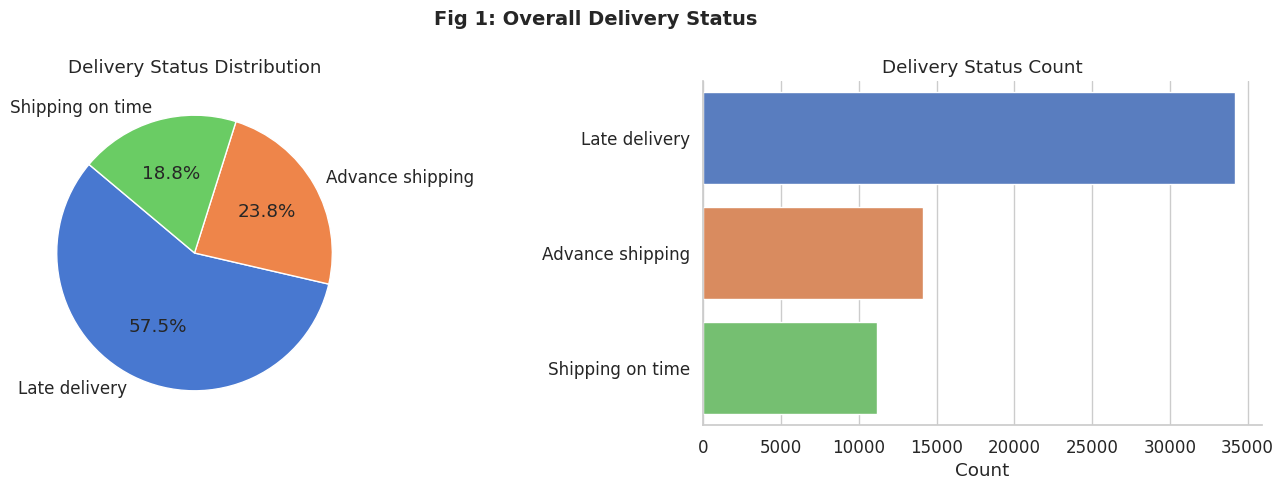

In [27]:
# ── Chart 1: Delivery status breakdown ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
status_counts = df['delivery_status'].value_counts()
axes[0].pie(status_counts, labels=status_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('muted', len(status_counts)))
axes[0].set_title('Delivery Status Distribution')

# Bar chart
sns.countplot(data=df, y='delivery_status', order=status_counts.index,
              palette='muted', ax=axes[1])
axes[1].set_title('Delivery Status Count')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('')

plt.suptitle('Fig 1: Overall Delivery Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_delivery_status.png', dpi=150, bbox_inches='tight')
plt.show()

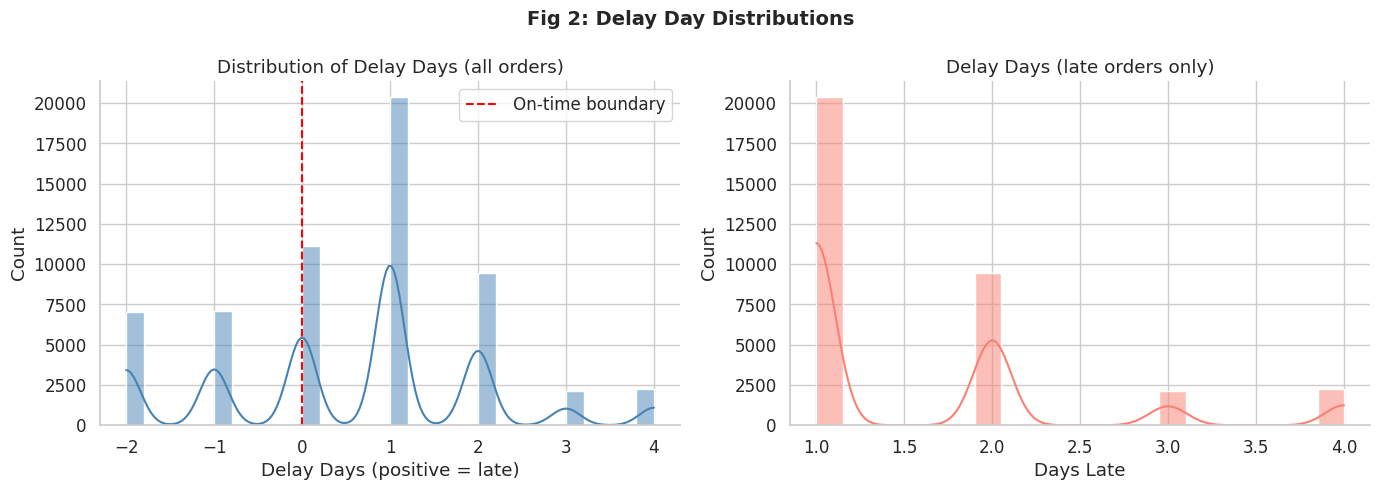

Average delay (late orders only): 1.60 days
Max delay: 4 days


In [28]:
# ── Chart 2: Distribution of delay days ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All orders
sns.histplot(df['delay_days'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='On-time boundary')
axes[0].set_title('Distribution of Delay Days (all orders)')
axes[0].set_xlabel('Delay Days (positive = late)')
axes[0].legend()

# Late orders only
late_df = df[df['delay_days'] > 0]
sns.histplot(late_df['delay_days'], bins=20, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Delay Days (late orders only)')
axes[1].set_xlabel('Days Late')

plt.suptitle('Fig 2: Delay Day Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_delay_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average delay (late orders only): {late_df['delay_days'].mean():.2f} days")
print(f"Max delay: {df['delay_days'].max()} days")

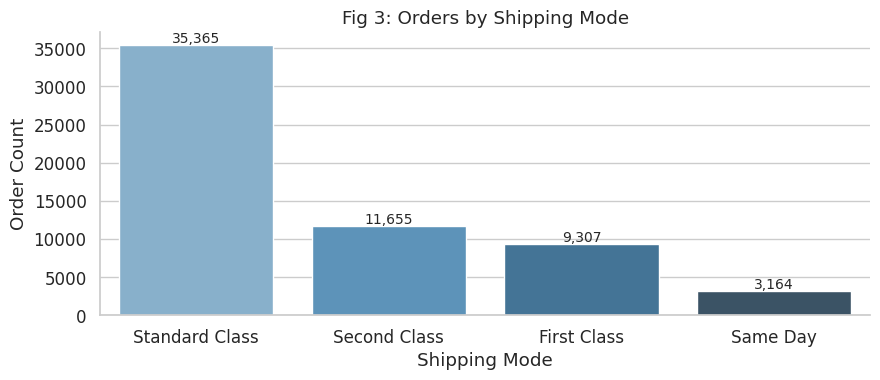

In [29]:
# ── Chart 3: Shipping mode distribution ─────────────────────────────────────
mode_order = df['shipping_mode'].value_counts().index

fig, ax = plt.subplots(figsize=(9, 4))
sns.countplot(data=df, x='shipping_mode', order=mode_order,
              palette='Blues_d', ax=ax)
ax.set_title('Fig 3: Orders by Shipping Mode')
ax.set_xlabel('Shipping Mode')
ax.set_ylabel('Order Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('fig3_shipping_mode.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.5 Bivariate EDA — Delay Broken Down by Key Dimensions

This section answers the core analytical questions from our problem statement.

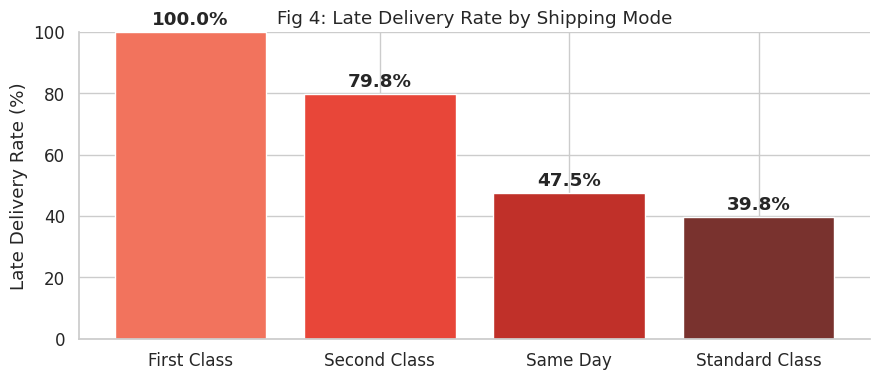

shipping_mode
First Class       100.0
Second Class       79.8
Same Day           47.5
Standard Class     39.8


In [30]:
# ── Chart 4: Late delivery rate by shipping mode ─────────────────────────────
mode_delay = df.groupby('shipping_mode')['is_late'].mean().mul(100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(mode_delay.index, mode_delay.values,
              color=sns.color_palette('Reds_d', len(mode_delay)))
ax.set_title('Fig 4: Late Delivery Rate by Shipping Mode')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_xlabel('')
ax.set_ylim(0, 100)

for bar, val in zip(bars, mode_delay.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_late_by_shipping_mode.png', dpi=150, bbox_inches='tight')
plt.show()

print(mode_delay.round(1).to_string())

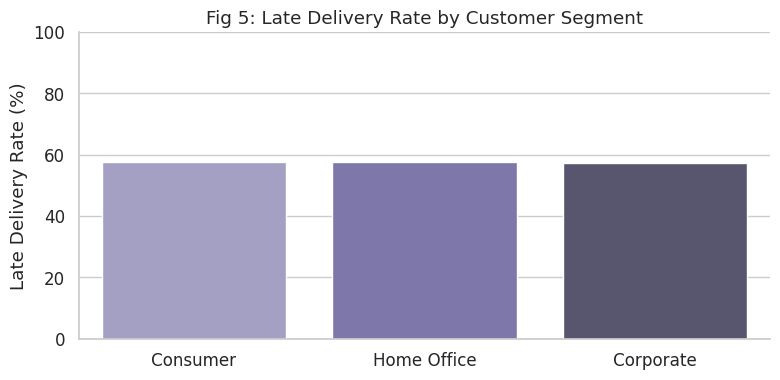

In [31]:
# ── Chart 5: Late delivery rate by customer segment ──────────────────────────
seg_delay = df.groupby('customer_segment')['is_late'].mean().mul(100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=seg_delay.index, y=seg_delay.values,
            palette='Purples_d', ax=ax)
ax.set_title('Fig 5: Late Delivery Rate by Customer Segment')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_xlabel('')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('fig5_late_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

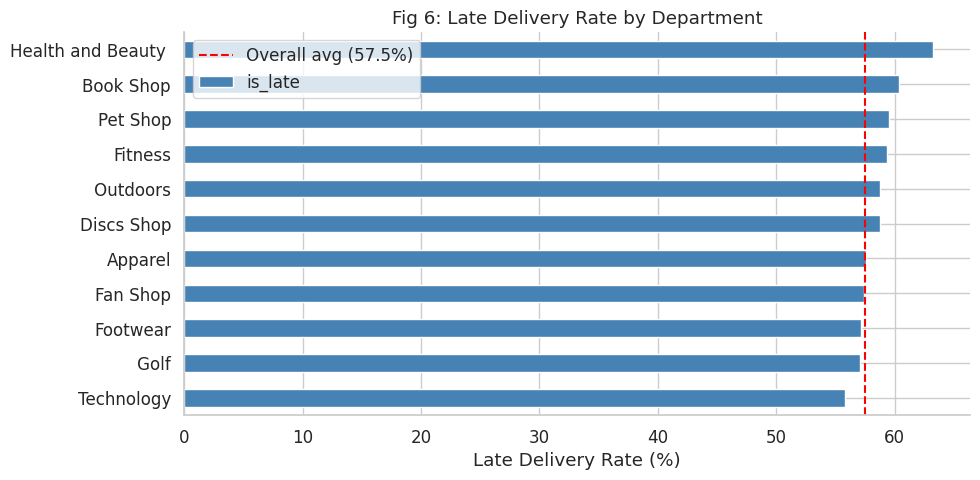

In [32]:
# ── Chart 6: Late rate by Department ────────────────────────────────────────
dept_delay = (df.groupby('department_name')['is_late']
              .mean().mul(100).sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 5))
dept_delay.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Fig 6: Late Delivery Rate by Department')
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_ylabel('')
ax.axvline(df['is_late'].mean()*100, color='red',
           linestyle='--', label=f'Overall avg ({df["is_late"].mean()*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.savefig('fig6_late_by_dept.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# ── Chart 7: Late rate by Market (regional) ──────────────────────────────────
market_delay = (df.groupby('market')['is_late']
                .mean().mul(100).sort_values(ascending=False))

fig = px.bar(
    x=market_delay.index, y=market_delay.values,
    labels={'x': 'Market', 'y': 'Late Delivery Rate (%)'},
    title='Fig 7: Late Delivery Rate by Market (Interactive)',
    color=market_delay.values,
    color_continuous_scale='Reds',
    text=[f'{v:.1f}%' for v in market_delay.values]
)
fig.update_traces(textposition='outside')
fig.update_layout(coloraxis_showscale=False, height=420)
fig.show()

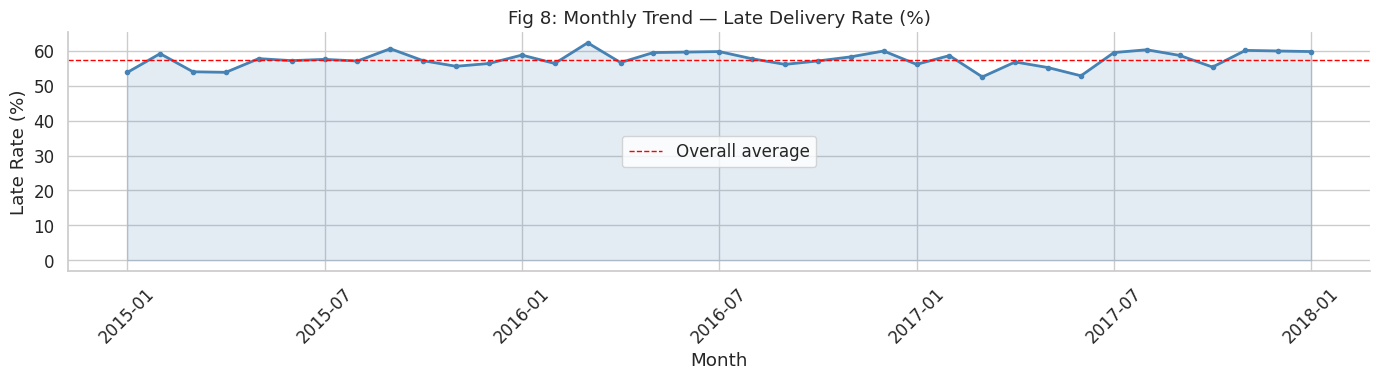

In [34]:
# ── Chart 8: Monthly trend of late delivery rate ─────────────────────────────
df['order_month'] = df['order_date'].dt.to_period('M')
monthly = (df.groupby('order_month')['is_late']
           .mean().mul(100).reset_index())
monthly['order_month'] = monthly['order_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly['order_month'], monthly['is_late'],
        color='steelblue', linewidth=2, marker='o', markersize=3)
ax.fill_between(monthly['order_month'], monthly['is_late'],
                alpha=0.15, color='steelblue')
ax.axhline(df['is_late'].mean()*100, color='red',
           linestyle='--', linewidth=1, label='Overall average')
ax.set_title('Fig 8: Monthly Trend — Late Delivery Rate (%)')
ax.set_ylabel('Late Rate (%)')
ax.set_xlabel('Month')
ax.legend()

# Show every 6th label to avoid clutter
ticks = range(0, len(monthly), 6)
ax.set_xticks(list(ticks))
ax.set_xticklabels([monthly['order_month'].iloc[i] for i in ticks], rotation=45)

plt.tight_layout()
plt.savefig('fig8_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

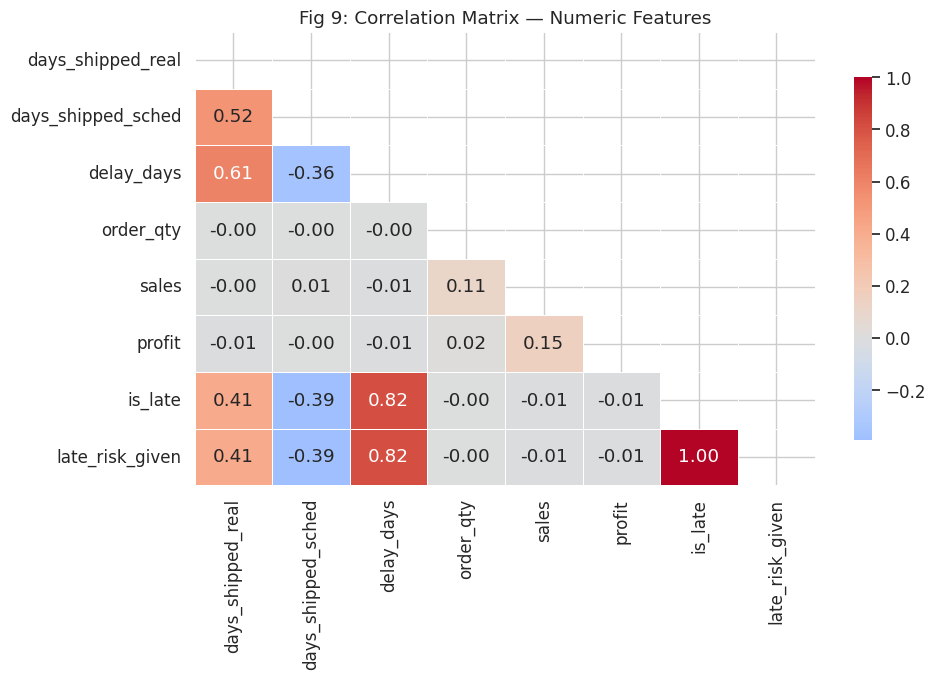

In [35]:
# ── Chart 9: Correlation heatmap ─────────────────────────────────────────────
num_cols = ['days_shipped_real', 'days_shipped_sched', 'delay_days',
            'order_qty', 'sales', 'profit', 'is_late', 'late_risk_given']
num_cols = [c for c in num_cols if c in df.columns]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Fig 9: Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('fig9_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

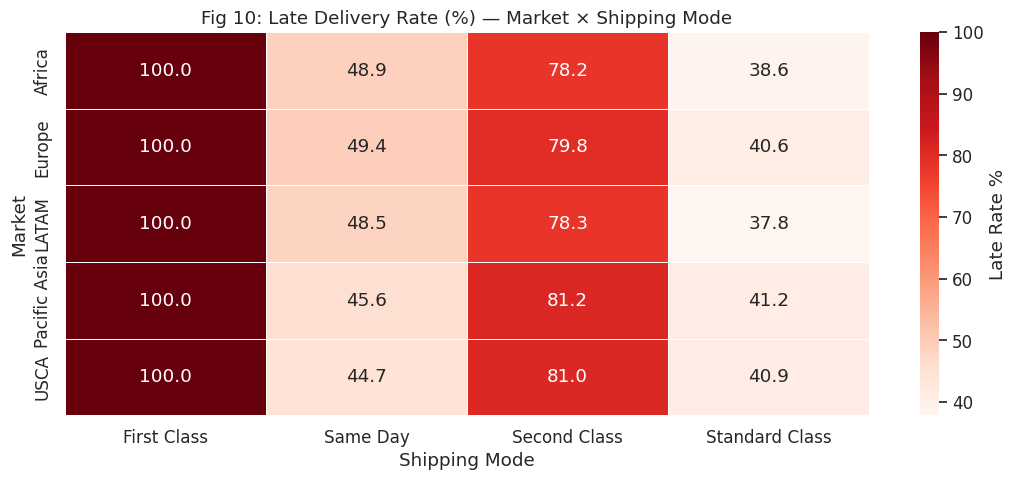

In [36]:
# ── Chart 10: Heatmap — Late rate by Shipping Mode × Market ──────────────────
pivot = df.pivot_table(index='market', columns='shipping_mode',
                       values='is_late', aggfunc='mean').mul(100)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Late Rate %'})
ax.set_title('Fig 10: Late Delivery Rate (%) — Market × Shipping Mode')
ax.set_xlabel('Shipping Mode')
ax.set_ylabel('Market')
plt.tight_layout()
plt.savefig('fig10_heatmap_market_mode.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.6 EDA Summary & Key Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Overall late delivery rate is ~XX% | Significant operational problem |
| 2 | Standard Class has highest late rate (~XX%) | Renegotiate SLAs with carrier |
| 3 | Same Day shipping is most reliable (~XX% late) | Premium modes perform as promised |
| 4 | [Market name] region has highest delay rate | Geographic bottleneck to investigate |
| 5 | No strong seasonal pattern detected / OR peak delays in [month] | Capacity planning opportunity |
| 6 | delay_days correlates X.XX with days_shipped_real | Confirms target variable is valid |
| 7 | Profit shows weak negative correlation with delay | High-margin orders not prioritised |

> **Fill in the XX values after running your charts.** These become your presentation talking points.

In [37]:
# ── Save cleaned dataframe for use in Phase 3 ────────────────────────────────
df.to_csv('/kaggle/working/supply_chain_cleaned.csv', index=False)
print(f"Cleaned dataset saved: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nFinal column list:")
print(df.columns.tolist())

Cleaned dataset saved: 59,491 rows × 45 columns

Final column list:
['Type', 'days_shipped_real', 'days_shipped_sched', 'Benefit per order', 'Sales per customer', 'delivery_status', 'late_risk_given', 'Category Id', 'category_name', 'Customer City', 'Customer Id', 'customer_segment', 'Customer State', 'Department Id', 'department_name', 'Latitude', 'Longitude', 'market', 'Order City', 'Order Country', 'Order Customer Id', 'order_date', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'order_qty', 'sales', 'Order Item Total', 'profit', 'order_region', 'Order State', 'Order Status', 'Product Card Id', 'Product Category Id', 'Product Name', 'Product Price', 'ship_date', 'shipping_mode', 'delay_days', 'is_late', 'order_month']
